In [17]:
import torch
import torch.nn as nn

# Pull in what preprocessing produced
from torch.utils.data import DataLoader
import joblib

import os
print(os.getcwd())
DEVICE = torch.device('cpu')

# Load the preprocessor to get N_FEATURES
preprocessor = joblib.load('data/processed/preprocessor_fdae.joblib')
N_FEATURES = preprocessor['n_features']
print(f'N_FEATURES: {N_FEATURES}')

/home/vmuser/credit-card-fraud-detection-1
N_FEATURES: 44


In [26]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import joblib

# Load preprocessor
preprocessor_data = joblib.load('data/processed/preprocessor_fdae.joblib')
scaler = preprocessor_data['scaler']
feature_columns = preprocessor_data['feature_columns']

# Load and process data
df = pd.read_csv('data/raw/creditcard.csv')

# Feature engineering (must match exactly what preprocessing notebook does)
df['Hour'] = (df['Time'] % (24 * 3600)) // 3600
df['Day']  = df['Time'] // (24 * 3600)
df['Amount_log']  = np.log1p(df['Amount'])
df['Amount_sqrt'] = np.sqrt(df['Amount'])
top_features = ['V14', 'V4', 'V11', 'V12', 'V10']
for i, f1 in enumerate(top_features):
    for f2 in top_features[i + 1:]:
        df[f'{f1}_{f2}_interaction'] = df[f1] * df[f2]

# Split
X = df.drop(columns=['Class'])
y = df['Class']
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
normal_mask = y_temp == 0
X_normal, y_normal = X_temp[normal_mask], y_temp[normal_mask]
X_train, X_val, y_train, y_val = train_test_split(X_normal, y_normal, test_size=0.25, random_state=42)

# Scale using the already-fitted scaler
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=feature_columns)
X_val_s   = pd.DataFrame(scaler.transform(X_val),   columns=feature_columns)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=feature_columns)

# Build dataloaders
def make_tensor(df): return torch.tensor(df.values, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(make_tensor(X_train_s)), batch_size=256, shuffle=True,  drop_last=True)
val_loader   = DataLoader(TensorDataset(make_tensor(X_val_s)),   batch_size=256, shuffle=False)
test_loader  = DataLoader(TensorDataset(make_tensor(X_test_s),   torch.tensor(y_test.values, dtype=torch.float32)), batch_size=256, shuffle=False)

print(f'train: {len(train_loader)} batches | val: {len(val_loader)} batches | test: {len(test_loader)} batches')

train: 666 batches | val: 223 batches | test: 223 batches


In [21]:
def add_gaussian_noise(x: torch.Tensor, noise_factor: float = 0.1) -> torch.Tensor:
    noise = torch.randn_like(x) * noise_factor
    return x + noise

In [18]:
class FDAE(nn.Module):
    
    def __init__(self, n_features: int):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ELU(),                    # ← ELU instead of ReLU
            nn.Linear(64, 32),
            nn.ELU(),
            nn.Linear(32, 16),
            nn.ELU(),
            nn.Linear(16, 8)             # ← no activation on latent
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ELU(),
            nn.Linear(16, 32),
            nn.ELU(),
            nn.Linear(32, 64),
            nn.ELU(),
            nn.Linear(64, n_features)    # ← no activation on output
        )
    
    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


# Initialise and sanity check
model = FDAE(n_features=N_FEATURES)
print(model)

dummy = torch.randn(8, N_FEATURES)
x_hat, z = model(dummy)
print(f'Input  : {dummy.shape}')
print(f'Output : {x_hat.shape}')
print(f'Latent : {z.shape}')

FDAE(
  (encoder): Sequential(
    (0): Linear(in_features=44, out_features=64, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=16, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=32, out_features=64, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=64, out_features=44, bias=True)
  )
)
Input  : torch.Size([8, 44])
Output : torch.Size([8, 44])
Latent : torch.Size([8, 8])


In [19]:
def fdae_loss(x_hat, x_clean, z, lambda1=0.5):
    """
    Combined loss for the FDAE.
    
    Args:
        x_hat   : reconstructed output from the model
        x_clean : original clean input (before noise was added)
        z       : latent vector from the encoder
        lambda1 : weight for the latent regularisation term
    
    Returns:
        total loss, reconstruction loss, latent loss  (all three for logging)
    """
    # Reconstruction + denoising (one term, two jobs)
    l_recon = nn.functional.mse_loss(x_hat, x_clean)
    
    # Latent regularisation — push z toward origin
    zeros = torch.zeros_like(z)
    l_latent = nn.functional.mse_loss(z, zeros)
    
    # Combined
    total = l_recon + lambda1 * l_latent
    
    return total, l_recon, l_latent

In [22]:
# Sanity check
dummy_x = torch.randn(8, N_FEATURES)
dummy_x_noisy = add_gaussian_noise(dummy_x, noise_factor=0.1)

x_hat, z = model(dummy_x_noisy)
total, l_recon, l_latent = fdae_loss(x_hat, dummy_x, z)

print(f'Total loss  : {total.item():.4f}')
print(f'Recon loss  : {l_recon.item():.4f}')
print(f'Latent loss : {l_latent.item():.4f}')

Total loss  : 1.0584
Recon loss  : 1.0459
Latent loss : 0.0249


In [23]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [24]:
def train_fdae(model, train_loader, val_loader, optimizer, 
               epochs=50, noise_factor=0.1, lambda1=0.5):
    """
    Training loop for the FDAE.
    
    Each epoch:
      - trains on normal-only batches with noisy input
      - validates on normal-only val set
      - logs all three loss components
    """
    history = {
        'train_total': [], 'train_recon': [], 'train_latent': [],
        'val_total':   [], 'val_recon':   [], 'val_latent':   []
    }

    for epoch in range(epochs):

        # ── Training phase ──────────────────────────────────────
        model.train()
        train_total, train_recon, train_latent = 0, 0, 0

        for batch in train_loader:
            x_clean = batch[0]

            # Add noise for denoising objective
            x_noisy = add_gaussian_noise(x_clean, noise_factor)

            # Forward pass
            x_hat, z = model(x_noisy)

            # Loss
            loss, l_recon, l_latent = fdae_loss(x_hat, x_clean, z, lambda1)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_total  += loss.item()
            train_recon  += l_recon.item()
            train_latent += l_latent.item()

        # Average over batches
        n = len(train_loader)
        train_total  /= n
        train_recon  /= n
        train_latent /= n

        # ── Validation phase ─────────────────────────────────────
        model.eval()
        val_total, val_recon, val_latent = 0, 0, 0

        with torch.no_grad():
            for batch in val_loader:
                x_clean = batch[0]
                x_noisy = add_gaussian_noise(x_clean, noise_factor)
                x_hat, z = model(x_noisy)
                loss, l_recon, l_latent = fdae_loss(x_hat, x_clean, z, lambda1)
                val_total  += loss.item()
                val_recon  += l_recon.item()
                val_latent += l_latent.item()

        n = len(val_loader)
        val_total  /= n
        val_recon  /= n
        val_latent /= n

        # ── Logging ──────────────────────────────────────────────
        history['train_total'].append(train_total)
        history['train_recon'].append(train_recon)
        history['train_latent'].append(train_latent)
        history['val_total'].append(val_total)
        history['val_recon'].append(val_recon)
        history['val_latent'].append(val_latent)

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:3d}/{epochs} | '
                  f'Train: {train_total:.4f} (recon {train_recon:.4f}, latent {train_latent:.4f}) | '
                  f'Val: {val_total:.4f} (recon {val_recon:.4f}, latent {val_latent:.4f})')

    return history

In [27]:
history = train_fdae(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    epochs=50,
    noise_factor=0.1,
    lambda1=0.5
)

Epoch   5/50 | Train: 1.4402 (recon 1.3906, latent 0.0991) | Val: 1.2311 (recon 1.1970, latent 0.0681)
Epoch  10/50 | Train: 1.1375 (recon 1.0956, latent 0.0838) | Val: 1.0628 (recon 1.0349, latent 0.0558)
Epoch  15/50 | Train: 1.0005 (recon 0.9693, latent 0.0624) | Val: 0.9001 (recon 0.8752, latent 0.0497)
Epoch  20/50 | Train: 0.9609 (recon 0.9310, latent 0.0597) | Val: 0.8116 (recon 0.7876, latent 0.0479)
Epoch  25/50 | Train: 0.8572 (recon 0.8300, latent 0.0542) | Val: 0.8396 (recon 0.8203, latent 0.0386)
Epoch  30/50 | Train: 0.7031 (recon 0.6782, latent 0.0497) | Val: 0.7427 (recon 0.7252, latent 0.0351)
Epoch  35/50 | Train: 0.9633 (recon 0.9392, latent 0.0480) | Val: 0.7564 (recon 0.7370, latent 0.0388)
Epoch  40/50 | Train: 0.7047 (recon 0.6822, latent 0.0451) | Val: 0.6318 (recon 0.6151, latent 0.0336)
Epoch  45/50 | Train: 0.7281 (recon 0.7082, latent 0.0398) | Val: 0.5949 (recon 0.5792, latent 0.0315)
Epoch  50/50 | Train: 0.6457 (recon 0.6261, latent 0.0393) | Val: 0.7685 

In [28]:
torch.save(model.state_dict(), 'data/processed/fdae_model.pt')
print('Model saved.')

Model saved.


Matplotlib is building the font cache; this may take a moment.


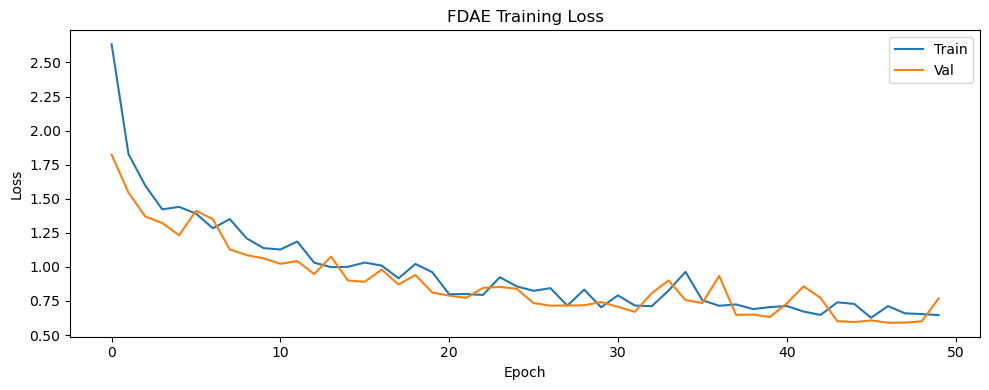

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(history['train_total'], label='Train')
plt.plot(history['val_total'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('FDAE Training Loss')
plt.legend()
plt.tight_layout()
plt.savefig('data/processed/loss_curve.png')
plt.show()

In [30]:
def compute_anomaly_scores(model, test_loader):
    """
    Compute per-transaction anomaly scores on the test set.
    
    Score = reconstruction error + latent distance
    No noise added — we want true reconstruction ability.
    
    Returns:
        scores : numpy array of anomaly scores, one per transaction
        labels : numpy array of true labels (0=normal, 1=fraud)
    """
    model.eval()
    all_scores = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            x_clean, y_true = batch

            # Forward pass — clean input, no noise
            x_hat, z = model(x_clean)

            # Reconstruction error per transaction
            recon_error = ((x_hat - x_clean) ** 2).mean(dim=1)

            # Latent distance per transaction
            latent_dist = (z ** 2).mean(dim=1)

            # Combined anomaly score
            score = recon_error + 0.5 * latent_dist

            all_scores.append(score.numpy())
            all_labels.append(y_true.numpy())

    scores = np.concatenate(all_scores)
    labels = np.concatenate(all_labels)

    return scores, labels


# Run it
scores, labels = compute_anomaly_scores(model, test_loader)

print(f'Test transactions : {len(scores):,}')
print(f'Fraud transactions: {int(labels.sum())}')
print(f'\nScore stats:')
print(f'  Normal — mean: {scores[labels==0].mean():.4f}, '
      f'max: {scores[labels==0].max():.4f}')
print(f'  Fraud  — mean: {scores[labels==1].mean():.4f}, '
      f'max: {scores[labels==1].max():.4f}')

Test transactions : 56,962
Fraud transactions: 98

Score stats:
  Normal — mean: 0.7682, max: 497.1116
  Fraud  — mean: 305.7768, max: 5065.3760


ROC-AUC Score        : 0.9624
Average Precision    : 0.5523


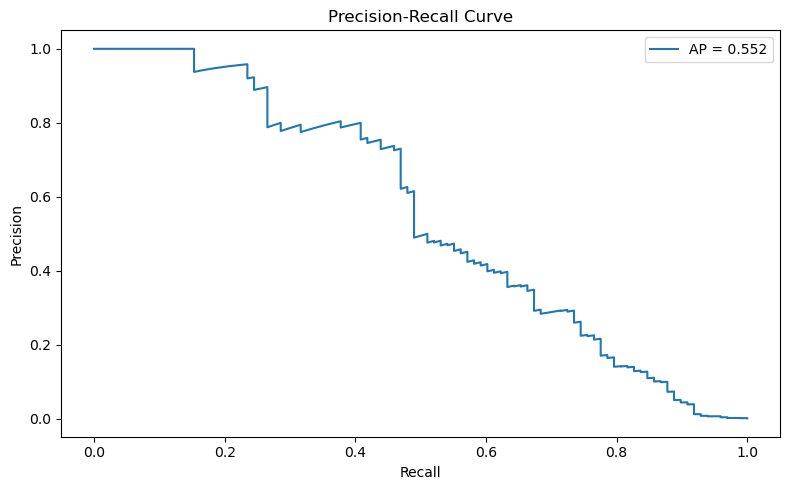


Best threshold : 89.2748
Best F1 score  : 0.5714

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.73      0.47      0.57        98

    accuracy                           1.00     56962
   macro avg       0.86      0.73      0.79     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56847    17]
 [   52    46]]


In [31]:
from sklearn.metrics import (precision_recall_curve, roc_auc_score,
                             classification_report, confusion_matrix,
                             average_precision_score)
import matplotlib.pyplot as plt

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(labels, scores)
avg_precision = average_precision_score(labels, scores)
roc_auc = roc_auc_score(labels, scores)

print(f'ROC-AUC Score        : {roc_auc:.4f}')
print(f'Average Precision    : {avg_precision:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'AP = {avg_precision:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.savefig('data/processed/pr_curve.png')
plt.show()

# Pick threshold that maximises F1
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f'\nBest threshold : {best_threshold:.4f}')
print(f'Best F1 score  : {best_f1:.4f}')

# Final classification report
predictions = (scores >= best_threshold).astype(int)
print('\nClassification Report:')
print(classification_report(labels, predictions, 
                            target_names=['Normal', 'Fraud']))

print('Confusion Matrix:')
print(confusion_matrix(labels, predictions))

In [32]:
custom_threshold = 50.0
predictions = (scores >= custom_threshold).astype(int)
print(classification_report(labels, predictions, target_names=['Normal', 'Fraud']))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.51      0.49      0.50        98

    accuracy                           1.00     56962
   macro avg       0.75      0.74      0.75     56962
weighted avg       1.00      1.00      1.00     56962



In [33]:
# Fresh model — reset weights
model = FDAE(n_features=N_FEATURES)

# Lower learning rate — fixes the instability we saw in the loss curve
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

# Retrain with adjustments
history = train_fdae(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    epochs=100,          # longer training
    noise_factor=0.15,   # slightly more noise — harder denoising task
    lambda1=0.8          # tighter latent space — pushes fraud further out
)

torch.save(model.state_dict(), 'data/processed/fdae_model_v2.pt')

Epoch   5/100 | Train: 1.7445 (recon 1.6934, latent 0.0638) | Val: 1.6207 (recon 1.5937, latent 0.0337)
Epoch  10/100 | Train: 1.4707 (recon 1.4344, latent 0.0454) | Val: 1.3986 (recon 1.3755, latent 0.0289)
Epoch  15/100 | Train: 1.2963 (recon 1.2659, latent 0.0381) | Val: 1.2500 (recon 1.2278, latent 0.0279)
Epoch  20/100 | Train: 1.1758 (recon 1.1473, latent 0.0356) | Val: 1.1737 (recon 1.1536, latent 0.0251)
Epoch  25/100 | Train: 0.9810 (recon 0.9513, latent 0.0371) | Val: 0.9494 (recon 0.9266, latent 0.0286)
Epoch  30/100 | Train: 0.8879 (recon 0.8614, latent 0.0332) | Val: 1.0073 (recon 0.9883, latent 0.0237)
Epoch  35/100 | Train: 0.8426 (recon 0.8191, latent 0.0294) | Val: 0.8055 (recon 0.7861, latent 0.0242)
Epoch  40/100 | Train: 0.8076 (recon 0.7857, latent 0.0274) | Val: 0.8185 (recon 0.8004, latent 0.0227)
Epoch  45/100 | Train: 0.7607 (recon 0.7406, latent 0.0251) | Val: 0.8088 (recon 0.7918, latent 0.0212)
Epoch  50/100 | Train: 0.7173 (recon 0.6985, latent 0.0234) | Va

In [34]:
# Evaluate v2
scores_v2, labels_v2 = compute_anomaly_scores(model, test_loader)

print(f'Score stats (v2):')
print(f'  Normal — mean: {scores_v2[labels_v2==0].mean():.4f}')
print(f'  Fraud  — mean: {scores_v2[labels_v2==1].mean():.4f}')

# Metrics
precision, recall, thresholds = precision_recall_curve(labels_v2, scores_v2)
avg_precision = average_precision_score(labels_v2, scores_v2)
roc_auc = roc_auc_score(labels_v2, scores_v2)

print(f'\nROC-AUC          : {roc_auc:.4f}')
print(f'Average Precision: {avg_precision:.4f}')

# Best threshold by F1
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

predictions = (scores_v2 >= best_threshold).astype(int)
print(f'\nBest threshold: {best_threshold:.4f}')
print('\nClassification Report:')
print(classification_report(labels_v2, predictions, target_names=['Normal', 'Fraud']))
print('Confusion Matrix:')
print(confusion_matrix(labels_v2, predictions))

Score stats (v2):
  Normal — mean: 0.5422
  Fraud  — mean: 224.0650

ROC-AUC          : 0.9618
Average Precision: 0.6515

Best threshold: 36.8118

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.73      0.56      0.64        98

    accuracy                           1.00     56962
   macro avg       0.87      0.78      0.82     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56844    20]
 [   43    55]]
